# Credit Card Fraud Detection (Capital One's dataset)

## EDA

In [5]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [6]:
dataset = 'transactions.txt'

df = pd.read_json(dataset,lines = True)

df.shape    #prints rows and columns

(786363, 29)

In [7]:
df.columns

Index(['accountNumber', 'customerId', 'creditLimit', 'availableMoney',
       'transactionDateTime', 'transactionAmount', 'merchantName',
       'acqCountry', 'merchantCountryCode', 'posEntryMode', 'posConditionCode',
       'merchantCategoryCode', 'currentExpDate', 'accountOpenDate',
       'dateOfLastAddressChange', 'cardCVV', 'enteredCVV', 'cardLast4Digits',
       'transactionType', 'echoBuffer', 'currentBalance', 'merchantCity',
       'merchantState', 'merchantZip', 'cardPresent', 'posOnPremises',
       'recurringAuthInd', 'expirationDateKeyInMatch', 'isFraud'],
      dtype='object')

In [8]:
# our target variable is isFraud, so

df['isFraud'].value_counts()

isFraud
False    773946
True      12417
Name: count, dtype: int64

### Observation 
1. it is an imbalanced dataset
2. fraud % is around 1-2% which is practically possible

df['isFraud'] gives us bool value for each row whereas .value_counts() counts respective value and gives us a summary of true and false

In [11]:
# to check which all columns are null and empty

df.isnull().sum()

accountNumber               0
customerId                  0
creditLimit                 0
availableMoney              0
transactionDateTime         0
transactionAmount           0
merchantName                0
acqCountry                  0
merchantCountryCode         0
posEntryMode                0
posConditionCode            0
merchantCategoryCode        0
currentExpDate              0
accountOpenDate             0
dateOfLastAddressChange     0
cardCVV                     0
enteredCVV                  0
cardLast4Digits             0
transactionType             0
echoBuffer                  0
currentBalance              0
merchantCity                0
merchantState               0
merchantZip                 0
cardPresent                 0
posOnPremises               0
recurringAuthInd            0
expirationDateKeyInMatch    0
isFraud                     0
dtype: int64

In [12]:
for col in df.columns:
    if df[col].dtype == 'object':
        empty_count = (df[col] == '').sum()
        print(col,':',empty_count)

transactionDateTime : 0
merchantName : 0
acqCountry : 4562
merchantCountryCode : 724
posEntryMode : 4054
posConditionCode : 409
merchantCategoryCode : 0
currentExpDate : 0
accountOpenDate : 0
dateOfLastAddressChange : 0
transactionType : 698
echoBuffer : 786363
merchantCity : 786363
merchantState : 786363
merchantZip : 786363
posOnPremises : 786363
recurringAuthInd : 786363


In [13]:
# now since 5-6 rows have all the columns empty we will drop them from the dataset since they don't add any value 

cols_to_drop = ['echoBuffer','merchantCity','merchantState','merchantZip','posOnPremises','recurringAuthInd']

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df.shape

(786363, 23)


inplace=True tells Pandas to modify the existing table directly in memory, instead of creating a copy of it.

errors='ignore' ensures that if you run the cell a second time, Python won't crash trying to delete columns that are already gone.

In [15]:
# checking for duplicates
# df.duplicated() checks for rows
duplicate = df.duplicated().sum()
duplicate

0

In [16]:
# now we will compre 2 variables, their mean, true transactions and fraud transactions

true_avg = df[df['isFraud']==False]['transactionAmount'].mean()
print('True avg : ',true_avg)
fraud_avg = df[df['isFraud']==True]['transactionAmount'].mean()
print('Fraud avg : ',fraud_avg)


True avg :  135.5702486219969
Fraud avg :  225.21590480792463


### Observation
therefore we can use transaction amout for our machine learning since the difference is considerable between true and fraud

In [18]:
df.columns

Index(['accountNumber', 'customerId', 'creditLimit', 'availableMoney',
       'transactionDateTime', 'transactionAmount', 'merchantName',
       'acqCountry', 'merchantCountryCode', 'posEntryMode', 'posConditionCode',
       'merchantCategoryCode', 'currentExpDate', 'accountOpenDate',
       'dateOfLastAddressChange', 'cardCVV', 'enteredCVV', 'cardLast4Digits',
       'transactionType', 'currentBalance', 'cardPresent',
       'expirationDateKeyInMatch', 'isFraud'],
      dtype='object')

In [19]:
# we will try to find out relation between currentbalance and available money

available_money_true_avg = df[df['isFraud']==False]['availableMoney'].mean()
print('Available money for True avg : ',available_money_true_avg)
available_money_fraud_avg = df[df['isFraud']==True]['availableMoney'].mean()
print('Available money for Fraud avg : ',available_money_fraud_avg)


current_balance_true_avg = df[df['isFraud']==False]['currentBalance'].mean()
print('Current balance for True avg : ',current_balance_true_avg)
current_balance_fraud_avg = df[df['isFraud']==True]['currentBalance'].mean()
print('Current balance for Fraud avg : ',current_balance_fraud_avg)

Available money for True avg :  6252.455386370623
Available money for Fraud avg :  6142.894186196344
Current balance for True avg :  4502.428675308096
Current balance for Fraud avg :  4902.064338407023


In [20]:
# we will find out for how many fraud cases transaction has happened through card

card_present_fraud = df[df['isFraud']==True]['cardPresent'].value_counts()
print('Fraud happened:', card_present_fraud)

card_present_true = df[df['isFraud']==False]['cardPresent'].value_counts()
print('True Transaction:', card_present_true)


Fraud happened: cardPresent
False    8962
True     3455
Name: count, dtype: int64
True Transaction: cardPresent
False    424533
True     349413
Name: count, dtype: int64


### Observation
we can't conclude any results from the available money and current balance because there is only a minor difference in the avg values 

For Legitimate Transactions:
Card NOT Present (False): 54.8%
Card Present (True): 45.2%
Meaning: For normal transactions, it is almost a 50/50 split. Legitimate customers shop online just slightly more than they shop in person.
For Fraudulent Transactions:
Card NOT Present (False): 72.2%
Card Present (True): 27.8%
Meaning: For fraud, the data is heavily skewed. Nearly 3 out of 4 fraud cases happen when the card is not physically present.
Conclusion: Because the percentage of "Card NOT Present" jumps significantly from 54.8% (normal) to 72.2% (fraud), this column is indeed a useful pattern that our machine learning models can use.


## Feature Corelation

We want to find out how our numerical columns relate to each other.

Correlation is a statistical measure (between -1 and 1) that tells us how closely two numbers move together:
A correlation close to 1 means directly proportional (e.g., height and weight).
A correlation close to -1 means inversely proportional (e.g., speed and travel time).
A correlation close to 0 means they have no relationship.

Here,

If credit limit increases, then transaction amount also increases.

As spending increases, your currentBalance goes UP (positive correlation).
As spending increases, your availableMoney goes DOWN (negative correlation).

We want to calculate the correlation matrix for only our four numerical columns: ['creditLimit', 'availableMoney', 'currentBalance', 'transactionAmount'].

In [24]:
# corelation matrix
corelation_matrix = df[['creditLimit', 'availableMoney', 'currentBalance', 'transactionAmount']].corr()

corelation_matrix

,creditLimit,availableMoney,currentBalance,transactionAmount
creditLimit,1.000000,0.834977,0.653652,0.005581
availableMoney,0.834977,1.000000,0.129332,-0.010070
currentBalance,0.653652,0.129332,1.000000,0.023905
transactionAmount,0.005581,-0.010070,0.023905,1.000000


<Axes: >

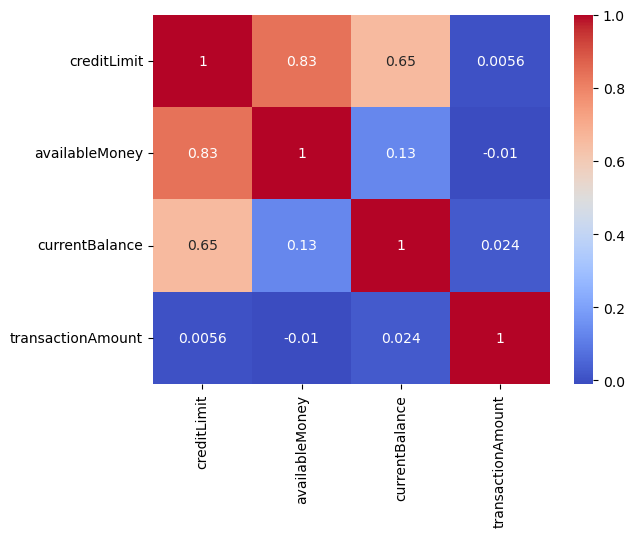

In [25]:
sns.heatmap(corelation_matrix, annot = True, cmap = 'coolwarm')

### Observation
1. credit limit and available money box has 0.83 which tells us that as customers credit limit goes up their available money also goes up.
2. ~0, size of a single transaction has zero linear relationship with how high a customer's credit limit is. A person with a $1,000 limit and a person with a $10,000 limit both buy coffee and groceries for similar average amounts.


## Data Cleaning

goal : identify and remove constant columns

constant column is a column where every single row contains the exact same value

For example, if all 786,363 transactions occurred in the "US", then the acqCountry column would contain "US" on every row.
thus provides zero useful information

now task is to check each column for unique value

In [28]:
constant_cols = []

for col in df.columns:
    if df[col].nunique() == True:
        constant_cols.append(col)

print("Constant columns found:", constant_cols)    

Constant columns found: []


there are no duplicate rows(checked in cell number 15) , empty columns are already removed, there are no constant columns(checked above)

next task is to fix missing values

check in cell 9 for columns having empty strings

there are 2 ways to handle these
1. to delete them
2. place a word like 'unknown'
   we will go with option 2 because If we delete rows just because a country code is missing, we might accidentally delete actual fraud transactions.

In [30]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace("", "Unknown")

# replace() has an inbuilt if statement, therefore we directly use replace instead of if to check if df[col] == ''

In [31]:
for col in df.columns:
    if df[col].dtype == 'object':
        empty_count = (df[col] == '').sum()
        print(col,':',empty_count)

transactionDateTime : 0
merchantName : 0
acqCountry : 0
merchantCountryCode : 0
posEntryMode : 0
posConditionCode : 0
merchantCategoryCode : 0
currentExpDate : 0
accountOpenDate : 0
dateOfLastAddressChange : 0
transactionType : 0


Therefore successfully placed a placeholder on the missing values 

next task is to identify and fix wrong datatypes
for ex : transactiondatetime are stored as object instead of numerical, similarly accountOpenDate, dateOfLastAddressChange, currentExpDate

if we leave them as it is then We cannot calculate the age of an account (e.g., transactionDateTime minus accountOpenDate). and so on.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786363 entries, 0 to 786362
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accountNumber             786363 non-null  int64  
 1   customerId                786363 non-null  int64  
 2   creditLimit               786363 non-null  int64  
 3   availableMoney            786363 non-null  float64
 4   transactionDateTime       786363 non-null  object 
 5   transactionAmount         786363 non-null  float64
 6   merchantName              786363 non-null  object 
 7   acqCountry                786363 non-null  object 
 8   merchantCountryCode       786363 non-null  object 
 9   posEntryMode              786363 non-null  object 
 10  posConditionCode          786363 non-null  object 
 11  merchantCategoryCode      786363 non-null  object 
 12  currentExpDate            786363 non-null  object 
 13  accountOpenDate           786363 non-null  o

In [34]:
# pd.to_datetime() function is used to change strings to dates

df['transactionDateTime'] = pd.to_datetime(df['transactionDateTime'])
df['accountOpenDate'] = pd.to_datetime(df['accountOpenDate'])
df['dateOfLastAddressChange'] = pd.to_datetime(df['dateOfLastAddressChange'])

df['currentExpDate'] = pd.to_datetime(df['currentExpDate'], format='%m/%Y')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786363 entries, 0 to 786362
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   accountNumber             786363 non-null  int64         
 1   customerId                786363 non-null  int64         
 2   creditLimit               786363 non-null  int64         
 3   availableMoney            786363 non-null  float64       
 4   transactionDateTime       786363 non-null  datetime64[ns]
 5   transactionAmount         786363 non-null  float64       
 6   merchantName              786363 non-null  object        
 7   acqCountry                786363 non-null  object        
 8   merchantCountryCode       786363 non-null  object        
 9   posEntryMode              786363 non-null  object        
 10  posConditionCode          786363 non-null  object        
 11  merchantCategoryCode      786363 non-null  object        
 12  cu

now we will compare cardcvv and enteredcvv column whether they match or not and save the resu,t in another column called cvvmatch

here, instead of using for loop logic 
for col in df.columns()
if df['cardcvv'] == df['enteredcvv']

we directly do it in a single line and store the result in another column

In [37]:
df['cvvMatch'] = df['cardCVV'] == df['enteredCVV']

now we will check for cvvmatches for fraud and notfraud transactions

In [39]:
cvv_match_fraud_transactions = df[df['isFraud'] == True]['cvvMatch'].value_counts()
print('CVV matches for Fraud transactions', cvv_match_fraud_transactions)

cvv_match_true_transactions = df[df['isFraud'] == False]['cvvMatch'].value_counts()
print('CVV matches for True transactions', cvv_match_true_transactions)

CVV matches for Fraud transactions cvvMatch
True     12214
False      203
Name: count, dtype: int64
CVV matches for True transactions cvvMatch
True     767134
False      6812
Name: count, dtype: int64


### Observation
1. Legitimate mismatch rate : 6812/773946 = 0.88% - therefore normal customers never get their cvv wrong
2. Fraud mismatch rate : 203/12214 = 1.64% - fraud transactions have a mismatch of 1.64%

next feature we will look at is the time feature, at what time the fraud happens
fraud often happens at odd times, we will check it

we converted date and time in proper format previously now we will use the .dt.hour function to extract the hour of the day (0 to 23), same for day of the month and month of the year and the day of the week(0 to 6)

In [42]:
df['transactionHour'] = df['transactionDateTime'].dt.hour
df['transactionDay'] = df['transactionDateTime'].dt.day
df['transactionMonth'] = df['transactionDateTime'].dt.month
df['transactionWeekday'] = df['transactionDateTime'].dt.weekday

df[['transactionHour','transactionDay','transactionMonth','transactionWeekday']].head()

,transactionHour,transactionDay,transactionMonth,transactionWeekday
0,14,13,8,5
1,5,11,10,1
2,9,8,11,1
3,2,10,12,5
4,21,24,3,3


now we will do binning of amount based features.
since transaction amount is a continuous variable we can categorize it as low, med, high, very high.
This helps our model quickly understand: "This is an unusually large purchase."

we do this using an inbuilt function call pd.cut() using pandas function

for pd.cut() we require 3 things
1. the column we want to split
2. the bins i.e boundary numbers
3. the labels for th bins

we will do bins as following - [0,50,200,500,float('inf')]
float('inf') means infinity
therefore 0 to 50, 50 to 200, 200 to 500 and 500 to infinity will be the bins

following is the format for pd.cut()
we will store the result in another column named amountBin
pd.cut(column_to_split, bins=[], labels=[])

In [44]:
df['amountBin'] = pd.cut(df['transactionAmount'], bins = [-100,50,200,500,float('inf')], labels = [0,1,2,3]).astype(int)

df[['amountBin']].head()

,amountBin
0,1
1,1
2,0
3,0
4,1


now we will check whether fraudsters make more veryHigh transactions

In [46]:
print('Fraud Transaction Bins')
print(df[df['isFraud'] == True]['amountBin'].value_counts())

print('Legitimate Transaction Bins')
print(df[df['isFraud'] == False]['amountBin'].value_counts())

Fraud Transaction Bins
amountBin
1    5132
2    4512
0    1723
3    1050
Name: count, dtype: int64
Legitimate Transaction Bins
amountBin
1    329175
0    264701
2    155734
3     24336
Name: count, dtype: int64


### Observation 

The veryHigh ($500+) Bin:

Legitimate: 24,336/751,843 ≈ 3.2%

Fraudulent:  1,050/12,295 ≈ 8.5%

Insight: A fraudulent transaction is nearly 3 times more likely to be in the "veryHigh" category compared to a legitimate one.

The high (200−500) Bin:

Legitimate: 

155,734/751,843 ≈ 20.7%

Fraudulent:  4,512/12,295 ≈ 36.7%

Insight: Fraud is heavily concentrated here. Over 36% of all fraud sits in this "high" bracket, compared to only 20% of normal spending.

The low (0−50) Bin:
Legitimate:  242,598/751,843 ≈ 32.3%

Fraudulent: 
1,601/12,295 ≈ 13.0%
Insight: Normal customers make tons of small purchases (coffee, snacks, parking), representing nearly a third of their spending. Fraudsters rarely bother with small amounts.

### Data Preprocessing

our next task is to convert all non numeric rows into numbers, because machine learning algorithms can perform calculations only on numbers

We have two standard ways to convert text categories into numbers:
1. One-Hot Encoding: Creating separate 0 or 1 columns for each category. (We use this when there is no order, like converting country codes "US", "MX", "CA").
2. Label Encoding (or Mapping): Assigning sequential numbers (e.g., 0, 1, 2, 3) to the categories. We use this when there is a natural order to the categories.

since our amountBins has a natural order we will go with label encoding. we do it using the .map() function 

we did it using .astype() in the earlier cell

In [49]:

df['cardPresent'] = df['cardPresent'].astype(int)
df['expirationDateKeyInMatch'] = df['expirationDateKeyInMatch'].astype(int)
df['cvvMatch'] = df['cvvMatch'].astype(int)

#.astype : In Python, False is mathematically 0 and True is mathematically 1. When we call .astype(int), Python automatically converts them.

now, Some of our categorical text columns do not have any natural order

transactionType (contains "PURCHASE", "REVERSAL", "Unknown")
We cannot assign 0, 1, and 2 here, because a machine learning model might assume that Unknown (2) is somehow "greater than" or "better than" PURCHASE (0), which makes no mathematical sense.

therefore we use One-Hot Encoding.

Instead of one column with three text values, we split it into three separate columns:
transactionType_PURCHASE (contains 1 or 0)
transactionType_REVERSAL (contains 1 or 0)
transactionType_Unknown (contains 1 or 0)

Pandas has an simple function to do this automatically: pd.get_dummies().

For example, we write:
df = pd.get_dummies(df, columns=['transactionType'])

In [51]:
columns_to_encode = ['acqCountry', 'merchantCountryCode', 'posEntryMode', 'posConditionCode', 'transactionType']

df = pd.get_dummies(df, columns = columns_to_encode)


In [52]:
print(df.shape)

(786363, 48)


In [53]:
df.columns

Index(['accountNumber', 'customerId', 'creditLimit', 'availableMoney',
       'transactionDateTime', 'transactionAmount', 'merchantName',
       'merchantCategoryCode', 'currentExpDate', 'accountOpenDate',
       'dateOfLastAddressChange', 'cardCVV', 'enteredCVV', 'cardLast4Digits',
       'currentBalance', 'cardPresent', 'expirationDateKeyInMatch', 'isFraud',
       'cvvMatch', 'transactionHour', 'transactionDay', 'transactionMonth',
       'transactionWeekday', 'amountBin', 'acqCountry_CAN', 'acqCountry_MEX',
       'acqCountry_PR', 'acqCountry_US', 'acqCountry_Unknown',
       'merchantCountryCode_CAN', 'merchantCountryCode_MEX',
       'merchantCountryCode_PR', 'merchantCountryCode_US',
       'merchantCountryCode_Unknown', 'posEntryMode_02', 'posEntryMode_05',
       'posEntryMode_09', 'posEntryMode_80', 'posEntryMode_90',
       'posEntryMode_Unknown', 'posConditionCode_01', 'posConditionCode_08',
       'posConditionCode_99', 'posConditionCode_Unknown',
       'transactionType_A

## Train Test Split

we need create two variables:
y (Target): This contains only our answer column, 'isFraud'.

X (Features): This contains our inputs. We will drop 'isFraud', but we also need to drop columns that are not useful for machine learning:
like Identifiers like acc no, customer id etc, Raw Dates since we have extracted hours, days etc, High-Cardinality Text like merchant names and merchant category code 


In [55]:
columns_to_drop = ['isFraud', 'accountNumber', 'customerId', 'cardLast4Digits', 'transactionDateTime', 'accountOpenDate', 'dateOfLastAddressChange', 'currentExpDate', 'merchantName', 'merchantCategoryCode']

X = df.drop(columns = columns_to_drop)

Y = df['isFraud']

In [56]:
print(X.shape)
print(Y.shape)

(786363, 38)
(786363,)


We will use Scikit-Learn's built-in function train_test_split to split our inputs X and targets Y into four separate pieces:

X_train and Y_train: The inputs and answers our models will study (80% of the data).


X_test and Y_test: The inputs and answers we will use to test our models (20% of the data).

we will use stratification. 

Because fraud is rare (only 1.58% of our data), a standard random split might accidentally put 2% of the fraud cases in the test set and only 1% in the training set.

By adding stratify=Y, we force Scikit-Learn to make sure that both the training set and the testing set contain exactly 1.58% fraud cases.

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 42)


test_size=0.2 : Tells the tool to allocate 20% of the rows to the test set (X_test and Y_test) and 80% of the rows to the training set.

stratify=Y : Tells the tool to look at the answers in Y and ensure that both the training and testing sets maintain the exact same 1.58% fraud ratio.

random_state=42 : What it does: This is a "seed" number for the random number generator.
Why we use it: Splitting is a random process. If you ran this notebook tomorrow without random_state=42, 
Python would make a slightly different random split, and your model scores would change. 
Setting random_state=42 ensures that the random split is reproducible—every time you run this notebook, you will get the exact same split.

In [60]:
print(X_train.shape)
print(X_test.shape)

(629090, 38)
(157273, 38)


## Scaling

We have several numerical columns with completely different ranges:

creditLimit and currentBalance can go up to thousands of dollars.

transactionHour only goes from 0 to 23.

All our One-Hot encoded columns are only 0 or 1.

If we feed these raw numbers directly into certain models (like Logistic Regression), the model will think that currentBalance is mathematically "more important" than transactionHour simply because the numbers are larger.

To scale our data, we will import StandardScaler from Scikit-Learn


Fit and Transform the Train Set: The scaler looks at X_train, calculates the average and standard deviation for each column (the fit part), and then scales the data (the transform part).

Only Transform the Test Set: The scaler scales the X_test data using the exact same averages it calculated from X_train. We do not run fit on the test set.

we must never use .fit() or .fit_transform() on our testing dataset because the machine uses the exact same averages it calculated from X_train to scale X_test. This treats your test set as completely unseen "future" data



In Scikit-Learn, the .fit_transform() and .transform() functions belong to the scaler tool itself

Create the tool: scaler = StandardScaler()

fit calculates the avg and var(std deviation) and transform applies scalling formula making their mean equal to 0 and std deviation equal to 1.

In [62]:
nan_counts = X_train.isnull().sum()

nan_counts

creditLimit                             0
availableMoney                          0
transactionAmount                       0
cardCVV                                 0
enteredCVV                              0
currentBalance                          0
cardPresent                             0
expirationDateKeyInMatch                0
cvvMatch                                0
transactionHour                         0
transactionDay                          0
transactionMonth                        0
transactionWeekday                      0
amountBin                               0
acqCountry_CAN                          0
acqCountry_MEX                          0
acqCountry_PR                           0
acqCountry_US                           0
acqCountry_Unknown                      0
merchantCountryCode_CAN                 0
merchantCountryCode_MEX                 0
merchantCountryCode_PR                  0
merchantCountryCode_US                  0
merchantCountryCode_Unknown       

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Class Imbalance

During training, our model looks at 100 transactions in X_train. Because 98.42 of them are legitimate, the model's mathematical brain will quickly realize: "If I just guess 'Legitimate' for every single transaction, I will get a 98.42% accuracy score"

therefore the algorithm will be heavily biased. 
___________

There can be 3 methods to handle the class imbalance

***Method 1: Class Weights (The Simplest & Cleanest)***

How it works: We tell the model: "Legitimate transactions are worth 1 point, but Fraudulent transactions are worth 60 points."
If the model misses a normal transaction, it gets penalized 1 point. But if it misses a fraud transaction, it gets penalized 60 points. This penalty forces the model to study the fraud cases extremely carefully.

Why it fits our level: It requires zero extra code or libraries. We simply pass a single parameter (class_weight='balanced') directly inside our Scikit-Learn models when we train them.


Method 2: SMOTE (Over-sampling)

How it works: We use a library to generate thousands of "fake" synthetic fraud transactions until we have a 50/50 balance in our training data.

The downside: It requires installing a separate library (imblearn) and increases our training data size significantly, which can slow down your computer.


Method 3: Under-sampling

How it works: We randomly delete 95% of our legitimate transactions until we have a 50/50 balance.

The downside: Deleting data means we throw away hundreds of thousands of real transactions, losing valuable patterns.

_______________________________________________________________________

**how we calculated the '60' value?**
its not a random guess.
legitimate transactions are 98.42% and fraud transactions are 1.58%, when we take the ratio of it, 

i.e 98.42 / 1.58 we get around 62, that means for every 1 fraud transaction there are 60 legitimate transactions

we will do it directly in logistic regression

but we only write 'balanced'. this word has inbuilt formula 

It counts how many legitimate transactions are in Y_train (roughly 619,150).

It counts how many fraudulent transactions are in Y_train (roughly 9,940).

It sees that legitimate transactions outnumber fraud by roughly 62 to 1.

Because you wrote 'balanced', the model automatically runs this standard formula under the hood:
Weight = Total rows / 2xrows in that class

## Basic Models

### Logistic Regression

In [66]:
nan_columns = X.isnull().sum()

nan_columns

creditLimit                             0
availableMoney                          0
transactionAmount                       0
cardCVV                                 0
enteredCVV                              0
currentBalance                          0
cardPresent                             0
expirationDateKeyInMatch                0
cvvMatch                                0
transactionHour                         0
transactionDay                          0
transactionMonth                        0
transactionWeekday                      0
amountBin                               0
acqCountry_CAN                          0
acqCountry_MEX                          0
acqCountry_PR                           0
acqCountry_US                           0
acqCountry_Unknown                      0
merchantCountryCode_CAN                 0
merchantCountryCode_MEX                 0
merchantCountryCode_PR                  0
merchantCountryCode_US                  0
merchantCountryCode_Unknown       

### Observation 

only 1 column i.e amountBin has NaN values

while running the LR model we got an error abouT THE NaN values, which means not a number, therefore we checked it and found out that amountBins column has 22225 rows which contain NaN values.

By default when we set out bins our 1st bin is exclusive of the left boundary, therefore transactions containing 0.00 were not included and also negative ones, 

therefore we change the bin from 0 to -100 

In [68]:
from sklearn.linear_model import LogisticRegression

#create the model
lr_model = LogisticRegression(class_weight = 'balanced', random_state = 42)

#train the model:
lr_model.fit(X_train_scaled, Y_train)

print("Logistic Regression model trained successfully")

#.fit(): This is the universal Scikit-Learn function for training. It feeds your scaled inputs (X_train_scaled) and answers (Y_train) into the model,
#allowing the algorithm to learn the mathematical coefficients for fraud.

Logistic Regression model trained successfully


.fit(): This is the "study" phase. The model looks at the training inputs and answers, and learns the patterns.

.predict(): This is the "test" phase. We give the model our unseen test inputs (X_test_scaled), and it outputs its guesses (which we will save in a variable called lr_preds).

In [70]:
lr_pred = lr_model.predict(X_test_scaled)

### Model Evaluation

we need 2 standard tools from scikitlearn
1. classification_report : This prints a table showing the Precision, Recall, and F1-Score for both classes (False / Legitimate and True / Fraud).
2. confusion_matrix : This prints a 2x2 grid showing exactly where the model succeeded and where it made errors.

To print the report, we pass the actual real-world answers (Y_test) and the model's guesses (lr_preds) inside them

In [72]:
from sklearn.metrics import classification_report, confusion_matrix

print('Classification Report : \n',classification_report(Y_test, lr_pred))
print('Confusion Matrix : \n',confusion_matrix(Y_test, lr_pred))

Classification Report : 
               precision    recall  f1-score   support

       False       0.99      0.67      0.80    154790
        True       0.03      0.68      0.06      2483

    accuracy                           0.67    157273
   macro avg       0.51      0.67      0.43    157273
weighted avg       0.98      0.67      0.79    157273

Confusion Matrix : 
 [[103347  51443]
 [   793   1690]]


### Observation

confusion matrix

[[ True Negatives (TN) , False Positives (FP) ]

 [ False Negatives (FN), True Positives (TP) ]]

1. Legitimate Transactions (Row 1):

**True Negatives (103,347) : Legitimate transactions that the model correctly guessed were legitimate.** (No action taken, customer is happy).

**False Positives (51,443): Legitimate transactions that the model incorrectly flagged as fraud.**

The Business Impact: These are false alarms. This means 51,443 innocent customers tried to buy something, but our baseline model blocked their cards. This causes a major customer service headache.

2. Fraudulent Transactions (Row 2):

**False Negatives (793): Actual fraudulent transactions that our model missed and allowed to go through.**

The Business Impact: The bank lost money on these 793 transactions.

**True Positives (1,690): Actual fraudulent transactions that our model successfully caught and blocked.**

Classification Report

Recall (0.68 or 68%)

What it means: Out of the 2,483 actual fraud cases in our test set, our model successfully caught 1,690 of them (1,690/2,483≈68%).

Evaluation: For a simple linear baseline model, catching 68% of fraud is a solid starting point.

Precision (0.03 or 3%)

What it means: Out of all the transactions our model flagged as fraud ( 51,443+1,690=53,133 total flags), only 3% of them were actually real fraud. The other 97% were false alarms.

Evaluation: This is very low. It means our model is being too aggressive. It is catching fraud, but it is causing a massive amount of collateral damage by blocking innocent users.


Logistic Regression is a linear model. It tries to draw a single straight line through your 38 columns to separate fraud from legitimate spending. Because real-world fraud is highly complex and non-linear, a straight line causes too many false alarms.

### Decision Tree Classifier

In [76]:
from sklearn.tree import DecisionTreeClassifier

#create model
dt_model = DecisionTreeClassifier(class_weight = 'balanced', random_state = 42)

#train model
dt_model.fit(X_train_scaled, Y_train)

print('DecisionTreeModel trained successfully')

DecisionTreeModel trained successfully


In [77]:
#test it
dt_pred = dt_model.predict(X_test_scaled)

### Model Evaluation

In [79]:
from sklearn.metrics import classification_report, confusion_matrix

print('Classification Report : \n',classification_report(Y_test, dt_pred))
print('Confusion Matrix : \n',confusion_matrix(Y_test, dt_pred))

Classification Report : 
               precision    recall  f1-score   support

       False       0.98      0.99      0.98    154790
        True       0.05      0.05      0.05      2483

    accuracy                           0.97    157273
   macro avg       0.52      0.52      0.52    157273
weighted avg       0.97      0.97      0.97    157273

Confusion Matrix : 
 [[152489   2301]
 [  2351    132]]


### Observation

It shows Overfitting

**A default DecisionTreeClassifier is a very eager learner. If we do not limit its size, it will keep growing branches until it memorizes your training data.**


Comparing the models:

Good:

False Positives (False Alarms): Dropped from 51,443 (Logistic Regression) down to only 2,301 (Decision Tree)!

Legitimate Recall: Rose to 99%.

The Business Impact: Legitimate customers are incredibly happy. We are almost never blocking their cards anymore.

Bad:

True Positives (Caught Fraud): Dropped from 1,690 down to only 132!

False Negatives (Missed Fraud): Rose to 2,351.

Fraud Recall: Dropped to 5% (132/2,483≈5%).

The Business Impact: This is a financial disaster for the bank. We are missing 95% of all fraud cases


In [81]:
dt_model_tuned = DecisionTreeClassifier(class_weight = 'balanced', random_state = 42, max_depth = 5)

#train model
dt_model_tuned.fit(X_train_scaled, Y_train)

print('DecisionTreeModel trained successfully')

DecisionTreeModel trained successfully


In [82]:
#test it
dt_pred_tuned = dt_model_tuned.predict(X_test_scaled)

In [83]:
from sklearn.metrics import classification_report, confusion_matrix

print('Classification Report of Tuned DecisionTree : \n',classification_report(Y_test, dt_pred_tuned))
print('Confusion Matrix of Tuned DecisionTree : \n',confusion_matrix(Y_test, dt_pred_tuned))

Classification Report of Tuned DecisionTree : 
               precision    recall  f1-score   support

       False       0.99      0.68      0.81    154790
        True       0.03      0.67      0.06      2483

    accuracy                           0.68    157273
   macro avg       0.51      0.68      0.44    157273
weighted avg       0.98      0.68      0.80    157273

Confusion Matrix of Tuned DecisionTree : 
 [[105843  48947]
 [   826   1657]]


### Observation

True Positives (Caught Fraud): Rose from 132 all the way up to 1,657!

Fraud Recall: Rose from 5% to 67%!

By limiting the tree to only 5 levels, we stopped it from memorizing the highly specific "noise" of the training data. The tree was forced to only use the 5 most general, powerful rules. Because these general rules exist in both the train and test sets, the model generalized successfully and caught 67% of the fraud.

## Advanced Models

### Random Forest 

What is a Random Forest?

Instead of relying on one single Decision Tree to make all the decisions, a Random Forest trains an entire ensemble (usually 100 trees by default).

How it works: Each of the 100 trees is trained on a slightly different random subset of your transactions and a random subset of your features.

The Voting Process: When a new transaction comes in, all 100 trees look at it and "vote" on whether it is fraud. If the majority of trees vote "Fraud," the transaction is blocked. This democratic voting process naturally smooths out individual tree errors, dramatically reducing false alarms (False Positives) while keeping our fraud recall high.

In [86]:
from sklearn.ensemble import RandomForestClassifier

#create model
rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 10, class_weight = 'balanced', random_state = 42)
#train model
rf_model.fit(X_train_scaled, Y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [87]:
#test it
rf_pred = rf_model.predict(X_test_scaled)

In [88]:
from sklearn.metrics import classification_report, confusion_matrix

print('Classification Report of Random Forest : \n',classification_report(Y_test, rf_pred))
print('Confusion Matrix of Random Forest : \n',confusion_matrix(Y_test, rf_pred))

Classification Report of Random Forest : 
               precision    recall  f1-score   support

       False       0.99      0.75      0.85    154790
        True       0.04      0.62      0.07      2483

    accuracy                           0.75    157273
   macro avg       0.51      0.68      0.46    157273
weighted avg       0.98      0.75      0.84    157273

Confusion Matrix of Random Forest : 
 [[115960  38830]
 [   953   1530]]


### XGBoost

In XGBoost, the trees are trained sequentially (one after another):

Tree #1 is trained on the data.

Tree #2 is trained specifically to correct the mistakes made by Tree #1 and so on.

XGBoost does not use the parameter class_weight='balanced', it uses a parameter called scale_pos_weight which is exact same concept.

Since we calculated our class ratio earlier as 62.3, we will set scale_pos_weight=62.3.


In [90]:
# xgboost is not installed in our jupyter notebook library therefore we need to install it

%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [91]:
from xgboost import XGBClassifier

xg_model = XGBClassifier(n_estimators = 100, max_depth = 10, scale_pos_weight = 62.3, random_state = 42)

#train the model
xg_model.fit(X_train_scaled, Y_train)

# test the model
xg_pred = xg_model.predict(X_test_scaled)

In [92]:
from sklearn.metrics import classification_report, confusion_matrix

print('Classification Report of XGBoost: \n',classification_report(Y_test, xg_pred))
print('Confusion Matrix of XGBoost : \n',confusion_matrix(Y_test, xg_pred))

Classification Report of XGBoost: 
               precision    recall  f1-score   support

       False       0.99      0.92      0.95    154790
        True       0.06      0.30      0.09      2483

    accuracy                           0.91    157273
   macro avg       0.52      0.61      0.52    157273
weighted avg       0.97      0.91      0.94    157273

Confusion Matrix of XGBoost : 
 [[142272  12518]
 [  1742    741]]


In Random Forest, trees are independent, so max_depth=10 is fine. But in XGBoost, trees build on top of each other. In boosting, a depth of 10 is actually extremely deep. Because the trees were too deep, the boosting algorithm overfit the training patterns

### Hyper parameter Tuning

In [95]:
xg_model_tuned = XGBClassifier(n_estimators = 100, max_depth = 4 , scale_pos_weight = 62.3, random_state = 42)

#train the model
xg_model_tuned.fit(X_train_scaled, Y_train)

# test the model
xg_pred_tuned = xg_model_tuned.predict(X_test_scaled)

In [96]:
print('Classification Report of XGBoost: \n',classification_report(Y_test, xg_pred_tuned))
print('Confusion Matrix of XGBoost : \n',confusion_matrix(Y_test, xg_pred_tuned))

Classification Report of XGBoost: 
               precision    recall  f1-score   support

       False       0.99      0.74      0.85    154790
        True       0.04      0.68      0.08      2483

    accuracy                           0.74    157273
   macro avg       0.52      0.71      0.46    157273
weighted avg       0.98      0.74      0.84    157273

Confusion Matrix of XGBoost : 
 [[115165  39625]
 [   796   1687]]


Let's compare this tuned XGBoost against our original Logistic Regression baseline (which also had 68% recall):

Logistic Regression: Caught 68% of fraud, but caused 51,443 false alarms.

Tuned XGBoost: Caught 68% of fraud, but caused only 39,625 false alarms.

The Business Impact: For the exact same fraud-catching capability, XGBoost saves nearly 12,000 legitimate customers from having their cards blocked compared to our baseline.

Which features do you intuitively expect the model found to be the most important? (Think about columns like transactionAmount, cardPresent, cvvMatch, or transactionHour).

### Model Explainability (Feature Importance)

In [99]:
importances = pd.DataFrame({ 'Feature': X.columns, 'Importance': xg_model_tuned.feature_importances_ })

# Sort the features from highest to lowest importance
importances = importances.sort_values(by='Importance', ascending=False)

# Display the top 10
print(importances.head(10))

                        Feature  Importance
25              posEntryMode_05    0.267408
6                   cardPresent    0.093315
2             transactionAmount    0.077485
26              posEntryMode_09    0.062694
29         posEntryMode_Unknown    0.046793
3                       cardCVV    0.031064
0                   creditLimit    0.030314
23  merchantCountryCode_Unknown    0.029543
31          posConditionCode_08    0.027841
4                    enteredCVV    0.027686
